In [1]:
# imports

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/ham10000_clean.csv")

In [2]:
# basic info

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   image_path    10015 non-null  str    
 8   width         10015 non-null  int64  
 9   height        10015 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 782.6 KB


,age,width,height
count,9958.000000,10015.0,10015.0
mean,51.863828,600.0,450.0
std,16.968614,0.0,0.0
min,0.000000,600.0,450.0
25%,40.000000,600.0,450.0
50%,50.000000,600.0,450.0
75%,65.000000,600.0,450.0
max,85.000000,600.0,450.0


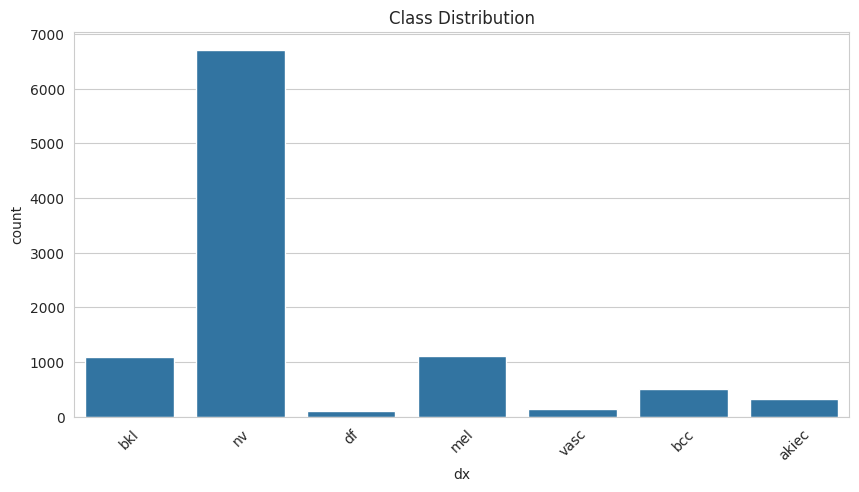

dx
nv       0.669496
mel      0.111133
bkl      0.109735
bcc      0.051323
akiec    0.032651
vasc     0.014179
df       0.011483
Name: proportion, dtype: float64

In [3]:
# class distribution

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="dx")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

df["dx"].value_counts(normalize=True)


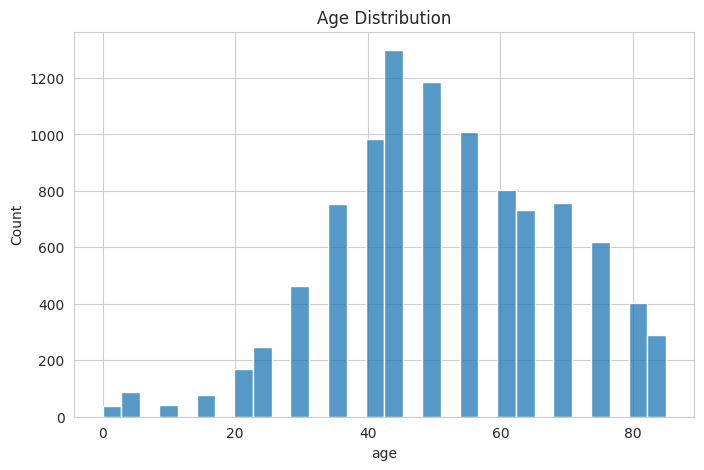

In [4]:
# age distribution

plt.figure(figsize=(8,5))
sns.histplot(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.show()

In [5]:
# sex distribution

px.histogram(df, x="sex", title="Sex Distribution")

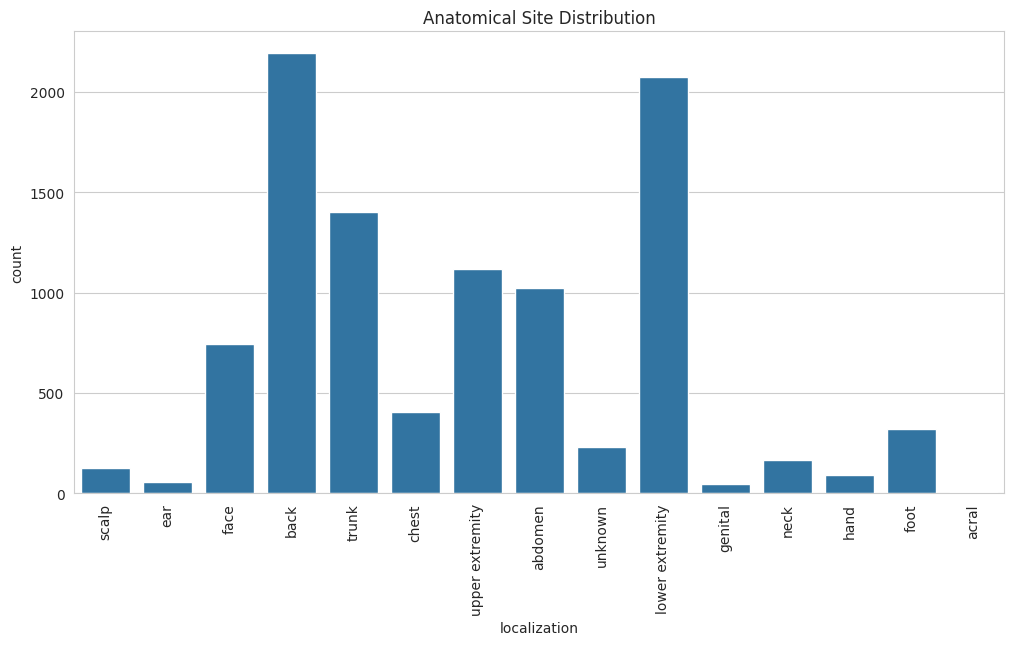

In [6]:
# anatomical localization

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="localization")
plt.xticks(rotation=90)
plt.title("Anatomical Site Distribution")
plt.show()

In [7]:
# resolution check

df[["width", "height"]].describe()

,width,height
count,10015.0,10015.0
mean,600.0,450.0
std,0.0,0.0
min,600.0,450.0
25%,600.0,450.0
50%,600.0,450.0
75%,600.0,450.0
max,600.0,450.0


In [8]:
df.columns.tolist()

['lesion_id',
 'image_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization',
 'image_path',
 'width',
 'height']

In [9]:
print("Total images:", len(df))
print("Unique lesions:", df["lesion_id"].nunique())
print("\nClass counts:\n", df["dx"].value_counts())

Total images: 10015
Unique lesions: 7470

Class counts:
 dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [10]:
images_per_lesion = df.groupby("lesion_id").size()

print("Average images per lesion:", images_per_lesion.mean())
print("Max images for a lesion:", images_per_lesion.max())

Average images per lesion: 1.3406961178045516
Max images for a lesion: 6


In [11]:
# class imbalance

max_class = df["dx"].value_counts().max()
min_class = df["dx"].value_counts().min()

print("Imbalance ratio:", round(max_class / min_class, 2))

Imbalance ratio: 58.3


In [12]:
# melanoma percentage

mel_pct = df["dx"].value_counts(normalize=True)["mel"] * 100
print(f"Melanoma percentage: {mel_pct:.2f}%")

Melanoma percentage: 11.11%


In [13]:
df.groupby("dx")["age"].mean().sort_values()

dx
nv       46.477477
vasc     51.373239
df       53.043478
mel      60.679568
bkl      64.283747
akiec    66.529052
bcc      66.828794
Name: age, dtype: float64

In [14]:
pd.crosstab(df["dx"], df["sex"])

sex,female,male,unknown
dx,,,
akiec,106,221,0
bcc,197,317,0
bkl,463,626,10
df,52,63,0
mel,424,689,0
nv,3237,3421,47
vasc,73,69,0


In [15]:
pd.crosstab(df["dx"], df["localization"])

localization,abdomen,acral,back,chest,ear,face,foot,genital,hand,lower extremity,neck,scalp,trunk,unknown,upper extremity
dx,,,,,,,,,,,,,,,
akiec,5,0,29,12,3,113,0,0,13,65,10,14,1,0,62
bcc,18,0,186,47,0,101,4,0,2,58,14,19,11,5,49
bkl,42,0,202,74,6,319,1,2,14,174,31,34,73,23,104
df,4,0,2,0,0,0,2,1,0,82,0,0,0,0,24
mel,66,0,324,68,17,104,28,0,1,192,29,14,47,10,213
nv,860,7,1427,200,30,100,284,45,55,1479,81,45,1241,196,655
vasc,27,0,22,6,0,8,0,0,5,27,3,2,31,0,11


In [16]:
df["dx"].value_counts(normalize=True)

dx
nv       0.669496
mel      0.111133
bkl      0.109735
bcc      0.051323
akiec    0.032651
vasc     0.014179
df       0.011483
Name: proportion, dtype: float64